# Backtesting the GARCH(1,1) baseline - gold

So far we've only looked at how well the model explains data it was fitted on (in-sample) - that flatters any model. This notebook actually tests it honestly:

1. Split the data in two, in time order: an early **training** period and a later **test** period.
2. Fit the model using *only* the training period - the test period stays completely unseen during fitting.
3. For every day in the test period, generate a genuine one-step-ahead forecast (made without knowing that day's actual return) and compare it to what actually happened.
4. Score those forecasts against a **naive benchmark** - "what if we just assumed volatility never changes?" - to see whether GARCH is actually earning its complexity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

## Load data and split into train / test

The split has to respect time order - no shuffling. We use the first 80% of days to train, and hold out the most recent 20% as the test period. This mimics reality: you only ever have the past to learn from, and you're judged on how well that generalizes to days you haven't seen yet.

In [2]:
gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
gold.index.name = "Date"

returns = gold["Close"].pct_change().dropna() * 100

split_idx = int(len(returns) * 0.8)
split_date = returns.index[split_idx]

print(f"Training period: {returns.index[0].date()} to {returns.index[split_idx - 1].date()} ({split_idx} days)")
print(f"Test period:     {split_date.date()} to {returns.index[-1].date()} ({len(returns) - split_idx} days)")

Training period: 2010-01-05 to 2023-04-11 (3336 days)
Test period:     2023-04-12 to 2026-08-05 (834 days)


## Fit using only the training period

`last_obs=split_date` tells `arch` to estimate omega, alpha, beta, mu using only data *before* that date - the test period has zero influence on the fitted parameters. Compare these to the full-sample fit from notebook 03 - they should be close but not identical, since this fit saw less data.

In [3]:
model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
result = model.fit(last_obs=split_date, disp="off")
result.params

mu          0.017917
omega       0.015810
alpha[1]    0.039925
beta[1]     0.944985
Name: params, dtype: float64

## Generate a one-step-ahead forecast for every day in the test period

`start=split_date` produces a forecast *at* every day from the split onward, each one predicting only the *very next* day (`horizon=1`), using the fixed training-period parameters. Each forecast still uses real returns to update the recursive formula day by day as the test period unfolds - that part isn't cheating, since knowing yesterday's actual return before forecasting today is exactly how this would work in real life. What's *not* allowed to change is the fitted omega/alpha/beta themselves, and they don't.

In [4]:
forecasts = result.forecast(start=split_date, horizon=1, reindex=False)
forecast_variance = forecasts.variance["h.1"]
forecast_volatility = np.sqrt(forecast_variance)
forecast_volatility.head()

Date
2023-04-12    1.075834
2023-04-13    1.094828
2023-04-14    1.139188
2023-04-17    1.117641
2023-04-18    1.101258
Name: h.1, dtype: float64

## Line up each forecast with what actually happened next

Each row above is dated on the day the forecast was *made*, but it's predicting the *next* day's swing. So we shift the return series back by one day to line up "the actual return that followed" with each forecast. We don't have a perfect measurement of "true" volatility for a single day, so we use the actual size of that day's move (absolute return) as the realized comparison point - a standard, simple stand-in.

In [5]:
next_day_return = returns.shift(-1).loc[forecast_volatility.index]
realized_move = next_day_return.abs()

valid = forecast_volatility.notna() & realized_move.notna()
forecast_volatility = forecast_volatility[valid]
realized_move = realized_move[valid]

comparison = pd.DataFrame({"Forecasted volatility": forecast_volatility, "Actual move (abs return)": realized_move})
comparison.head()

,Forecasted volatility,Actual move (abs return)
Date,,
2023-04-12,1.075834,1.511762
2023-04-13,1.094828,1.915451
2023-04-14,1.139188,0.399560
2023-04-17,1.117641,0.661923
2023-04-18,1.101258,0.607755


## Score it: GARCH vs. a naive "volatility never changes" benchmark

The naive benchmark: just use the training period's overall (flat, unconditional) volatility as the forecast for *every single day* in the test period - completely ignoring recent activity. If GARCH can't beat this simple-minded rule, GARCH isn't earning its extra complexity.

We score both using RMSE (root mean squared error) between forecasted volatility and the actual move size - lower is better.

In [6]:
train_returns = returns.loc[:returns.index[split_idx - 1]]
naive_volatility = train_returns.std()

rmse_garch = np.sqrt(np.mean((forecast_volatility - realized_move) ** 2))
rmse_naive = np.sqrt(np.mean((naive_volatility - realized_move) ** 2))

print(f"Naive flat volatility forecast: {naive_volatility:.4f}%")
print(f"GARCH(1,1) RMSE: {rmse_garch:.4f}")
print(f"Naive flat RMSE: {rmse_naive:.4f}")
print(f"GARCH improvement over naive: {(1 - rmse_garch / rmse_naive) * 100:.2f}%")

Naive flat volatility forecast: 1.0205%
GARCH(1,1) RMSE: 0.9032
Naive flat RMSE: 0.9276
GARCH improvement over naive: 2.63%


## Plot forecast vs. reality over the test period

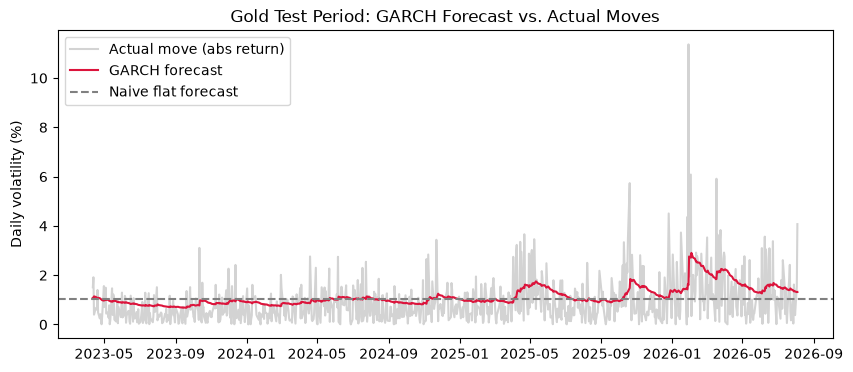

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(realized_move.index, realized_move, color="lightgray", label="Actual move (abs return)")
ax.plot(forecast_volatility.index, forecast_volatility, color="crimson", label="GARCH forecast")
ax.axhline(naive_volatility, color="gray", linestyle="--", label="Naive flat forecast")
ax.set_title("Gold Test Period: GARCH Forecast vs. Actual Moves")
ax.set_ylabel("Daily volatility (%)")
ax.legend()
plt.show()